# Chip Placement with Reinforcement Learning
## Comparing Random, Q-Learning, and DQN Agents

This notebook implements three approaches to place macros on a chip grid to minimize wirelength.

In [9]:
# Install required packages
!pip install torch gymnasium numpy matplotlib -q

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

print("All packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")

All packages imported successfully!
PyTorch version: 2.10.0+cpu


In [10]:
# ============================================
# Shared Environment for Chip Placement
# ============================================

class SimpleChipEnv:
    """Environment for placing macros on a grid to minimize wirelength"""

    def __init__(self, grid_size=6, num_macros=4):
        self.grid_size = grid_size
        self.num_macros = num_macros
        self.reset()

    def calculate_wirelength(self, positions):
        """Calculate total Manhattan distance between consecutive macros"""
        if len(positions) < 2:
            return 0
        total = 0
        for i in range(len(positions) - 1):
            x1, y1 = positions[i]
            x2, y2 = positions[i + 1]
            total += abs(x1 - x2) + abs(y1 - y2)
        return total

    def reset(self):
        """Reset environment to initial state"""
        self.grid = np.zeros((self.grid_size, self.grid_size))
        self.macros_placed = []
        self.step_count = 0
        return self.grid.copy()

    def step(self, action):
        """
        Take an action to place a macro
        For Q-Learning: action is (x, y) tuple
        For DQN: action is integer index (converted to coordinates)
        """
        # Handle both tuple and integer actions
        if isinstance(action, tuple):
            x, y = action
        else:
            x = action // self.grid_size
            y = action % self.grid_size

        if 0 <= x < self.grid_size and 0 <= y < self.grid_size and self.grid[x, y] == 0:
            self.grid[x, y] = 1
            self.macros_placed.append((x, y))
            self.step_count += 1
            wirelength = self.calculate_wirelength(self.macros_placed)
            reward = -wirelength  # Negative reward to minimize wirelength
            done = len(self.macros_placed) >= self.num_macros
            return self.grid.copy(), reward, done
        else:
            # Invalid placement (occupied or out of bounds)
            return self.grid.copy(), -10, False

    def render(self):
        """Print current grid state"""
        for row in self.grid:
            print(' '.join(['X' if cell == 1 else '.' for cell in row]))
        print()

In [11]:
# ============================================
# Q-Learning Agent Implementation
# ============================================

class QLearningAgent:
    """Tabular Q-Learning agent for chip placement"""

    def __init__(self, env, learning_rate=0.1, discount_factor=0.9, exploration_rate=0.3):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = exploration_rate
        self.q_table = {}

    def get_state_key(self):
        """Get unique key for current state based on placed macros"""
        return tuple(sorted(self.env.macros_placed))

    def get_action(self):
        """Select action using epsilon-greedy policy"""
        state_key = self.get_state_key()

        if random.random() < self.epsilon:
            # Explore: random action
            x = random.randint(0, self.env.grid_size - 1)
            y = random.randint(0, self.env.grid_size - 1)
            return (x, y)

        # Exploit: best known action
        if state_key not in self.q_table:
            self.q_table[state_key] = {}

        if len(self.q_table[state_key]) == 0:
            # No actions learned yet, explore
            x = random.randint(0, self.env.grid_size - 1)
            y = random.randint(0, self.env.grid_size - 1)
            return (x, y)

        best_action = max(self.q_table[state_key], key=self.q_table[state_key].get)
        return best_action

    def update(self, state, action, reward, next_state, done):
        """Update Q-values using Bellman equation"""
        state_key = tuple(sorted(state))
        next_state_key = tuple(sorted(next_state))

        if state_key not in self.q_table:
            self.q_table[state_key] = {}
        if action not in self.q_table[state_key]:
            self.q_table[state_key][action] = 0

        max_future_q = 0
        if next_state_key in self.q_table and len(self.q_table[next_state_key]) > 0:
            max_future_q = max(self.q_table[next_state_key].values())

        old_q = self.q_table[state_key][action]
        new_q = old_q + self.lr * (reward + self.gamma * max_future_q - old_q)
        self.q_table[state_key][action] = new_q

In [12]:
# ============================================
# DQN Neural Network and Agent
# ============================================

class DQN(nn.Module):
    """Deep Q-Network for chip placement"""

    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        return self.network(x)


class DQNAgent:
    """Deep Q-Learning agent with experience replay"""

    def __init__(self, env, learning_rate=0.001, discount_factor=0.9,
                 exploration_rate=1.0, exploration_decay=0.995,
                 exploration_min=0.01, memory_size=2000, batch_size=32):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = exploration_rate
        self.epsilon_decay = exploration_decay
        self.epsilon_min = exploration_min
        self.batch_size = batch_size
        self.memory = deque(maxlen=memory_size)

        self.input_dim = env.grid_size * env.grid_size
        self.output_dim = env.grid_size * env.grid_size

        self.policy_net = DQN(self.input_dim, self.output_dim)
        self.target_net = DQN(self.input_dim, self.output_dim)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)

        self.target_net.load_state_dict(self.policy_net.state_dict())

    def get_state_tensor(self, grid):
        """Convert grid to tensor for neural network input"""
        return torch.FloatTensor(grid.flatten()).unsqueeze(0)

    def get_action(self, grid):
        """Select action using epsilon-greedy policy"""
        if random.random() < self.epsilon:
            return random.randint(0, self.env.grid_size * self.env.grid_size - 1)

        state_tensor = self.get_state_tensor(grid)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay memory"""
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        """Train on random batch from memory"""
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)

        for state, action, reward, next_state, done in batch:
            state_tensor = self.get_state_tensor(state)
            next_state_tensor = self.get_state_tensor(next_state)

            current_q = self.policy_net(state_tensor)[0][action]

            if done:
                target_q = torch.tensor(reward, dtype=torch.float32)
            else:
                with torch.no_grad():
                    next_q = self.target_net(next_state_tensor).max()
                target_q = torch.tensor(reward, dtype=torch.float32) + self.gamma * next_q

            loss = nn.MSELoss()(current_q, target_q)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def update_target_network(self):
        """Copy policy network weights to target network"""
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [13]:
# ============================================
# Train Q-Learning Agent
# ============================================

print("=" * 50)
print("Training Q-Learning Agent - 500 Episodes")
print("=" * 50)

env_ql = SimpleChipEnv(grid_size=6, num_macros=4)
agent_ql = QLearningAgent(env_ql)

num_episodes_ql = 500
episode_rewards_ql = []

for episode in range(num_episodes_ql):
    state = env_ql.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent_ql.get_action()
        next_state, reward, done = env_ql.step(action)
        agent_ql.update(env_ql.macros_placed[:-1], action, reward, env_ql.macros_placed, done)
        total_reward += reward

    episode_rewards_ql.append(total_reward)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards_ql[-50:])
        print(f"Episode {episode+1}: Average Reward = {avg_reward:.2f}")

print("\nQ-Learning Training Complete!")
print(f"Best reward achieved: {max(episode_rewards_ql)}")
print(f"Average reward over last 50 episodes: {np.mean(episode_rewards_ql[-50:]):.2f}")

Training Q-Learning Agent - 500 Episodes
Episode 50: Average Reward = -25.42
Episode 100: Average Reward = -22.08
Episode 150: Average Reward = -22.92
Episode 200: Average Reward = -21.78
Episode 250: Average Reward = -26.72
Episode 300: Average Reward = -21.36
Episode 350: Average Reward = -20.92
Episode 400: Average Reward = -24.04
Episode 450: Average Reward = -21.90
Episode 500: Average Reward = -23.28

Q-Learning Training Complete!
Best reward achieved: -6
Average reward over last 50 episodes: -23.28


In [6]:
# ============================================
# Train DQN Agent
# ============================================

print("\n" + "=" * 50)
print("Training DQN Agent - 200 Episodes")
print("=" * 50)

env_dqn = SimpleChipEnv(grid_size=6, num_macros=4)
agent_dqn = DQNAgent(env_dqn)

num_episodes_dqn = 200
episode_rewards_dqn = []

for episode in range(num_episodes_dqn):
    state = env_dqn.reset()
    total_reward = 0
    done = False

    while not done:
        action = agent_dqn.get_action(state)
        next_state, reward, done = env_dqn.step(action)
        agent_dqn.remember(state, action, reward, next_state, done)
        agent_dqn.replay()
        state = next_state
        total_reward += reward

    episode_rewards_dqn.append(total_reward)

    if (episode + 1) % 10 == 0:
        agent_dqn.update_target_network()

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards_dqn[-50:])
        print(f"Episode {episode+1}: Average Reward = {avg_reward:.2f}, Epsilon = {agent_dqn.epsilon:.3f}")

print("\nDQN Training Complete!")
print(f"Best reward achieved: {max(episode_rewards_dqn)}")
print(f"Average reward over last 50 episodes: {np.mean(episode_rewards_dqn[-50:]):.2f}")


Training DQN Agent - 200 Episodes
Episode 50: Average Reward = -27.84, Epsilon = 0.373
Episode 100: Average Reward = -26.64, Epsilon = 0.114
Episode 150: Average Reward = -22.28, Epsilon = 0.039
Episode 200: Average Reward = -16.28, Epsilon = 0.013

DQN Training Complete!
Best reward achieved: -6
Average reward over last 50 episodes: -16.28


In [7]:
# ============================================
# DEMO: DQN Agent Placing Macros
# ============================================

print("\n" + "=" * 50)
print("DEMO: DQN Agent Placing Macros")
print("=" * 50)

# Create fresh environment for demonstration
env_demo = SimpleChipEnv(grid_size=6, num_macros=4)
# Use the trained DQN agent (if trained above, or create new one)
agent_demo = DQNAgent(env_demo)

# Optional: Load trained weights if you saved them
# agent_demo.policy_net.load_state_dict(torch.load('dqn_chip_placement.pth'))

state = env_demo.reset()
print("Initial Grid (empty):")
env_demo.render()

total_reward = 0
step = 1

while True:
    action = agent_demo.get_action(state)
    next_state, reward, done = env_demo.step(action)
    total_reward += reward

    x = action // env_demo.grid_size
    y = action % env_demo.grid_size
    print(f"Step {step}: Placed macro at ({x}, {y})")
    print(f"Reward: {reward}")
    print("Current grid:")
    env_demo.render()

    step += 1
    state = next_state

    if done:
        break

print("=" * 50)
print("DEMO COMPLETE!")
print(f"Total macros placed: {len(env_demo.macros_placed)}")
print(f"Final wirelength: {env_demo.calculate_wirelength(env_demo.macros_placed)}")
print(f"Total reward: {total_reward}")
print(f"Final positions: {env_demo.macros_placed}")
print("=" * 50)


DEMO: DQN Agent Placing Macros
Initial Grid (empty):
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .

Step 1: Placed macro at (3, 3)
Reward: 0
Current grid:
. . . . . .
. . . . . .
. . . . . .
. . . X . .
. . . . . .
. . . . . .

Step 2: Placed macro at (4, 3)
Reward: -1
Current grid:
. . . . . .
. . . . . .
. . . . . .
. . . X . .
. . . X . .
. . . . . .

Step 3: Placed macro at (0, 3)
Reward: -5
Current grid:
. . . X . .
. . . . . .
. . . . . .
. . . X . .
. . . X . .
. . . . . .

Step 4: Placed macro at (3, 4)
Reward: -9
Current grid:
. . . X . .
. . . . . .
. . . . . .
. . . X X .
. . . X . .
. . . . . .

DEMO COMPLETE!
Total macros placed: 4
Final wirelength: 9
Total reward: -15
Final positions: [(3, 3), (4, 3), (0, 3), (3, 4)]


COMPARISON: Random vs Q-Learning vs DQN
Testing Random Agent...
Random Agent Average Reward: -27.40
Q-Learning Average Reward (last 50): -27.66
DQN Average Reward (last 50): -16.28

--------------------------------------------------
IMPROVEMENTS:
Q-Learning vs Random: 0.9% better
DQN vs Random: -40.6% better


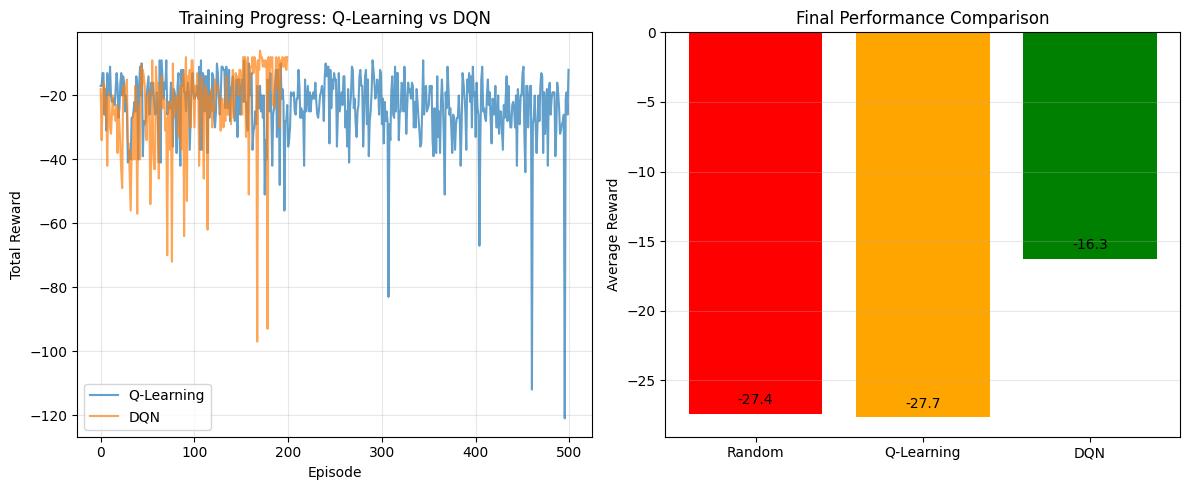

In [8]:
# ============================================
# Comparison: Random vs Q-Learning vs DQN
# ============================================

print("=" * 50)
print("COMPARISON: Random vs Q-Learning vs DQN")
print("=" * 50)

# Test Random Agent
env_random = SimpleChipEnv(grid_size=6, num_macros=4)
random_rewards = []
print("Testing Random Agent...")
for _ in range(50):
    state = env_random.reset()
    total = 0
    done = False
    while not done:
        action = random.randint(0, 35)
        next_state, reward, done = env_random.step(action)
        total += reward
    random_rewards.append(total)
random_avg = np.mean(random_rewards)
print(f"Random Agent Average Reward: {random_avg:.2f}")

# Q-Learning results
ql_avg = np.mean(episode_rewards_ql[-50:])
print(f"Q-Learning Average Reward (last 50): {ql_avg:.2f}")

# DQN results
dqn_avg = np.mean(episode_rewards_dqn[-50:])
print(f"DQN Average Reward (last 50): {dqn_avg:.2f}")

print("\n" + "-" * 50)
print("IMPROVEMENTS:")
improvement_ql = ((random_avg - ql_avg) / abs(random_avg)) * 100
improvement_dqn = ((random_avg - dqn_avg) / abs(random_avg)) * 100
print(f"Q-Learning vs Random: {improvement_ql:.1f}% better")
print(f"DQN vs Random: {improvement_dqn:.1f}% better")

# Plotting results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(episode_rewards_ql, label='Q-Learning', alpha=0.7)
plt.plot(episode_rewards_dqn, label='DQN', alpha=0.7)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Training Progress: Q-Learning vs DQN')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
agents = ['Random', 'Q-Learning', 'DQN']
scores = [random_avg, ql_avg, dqn_avg]
colors = ['red', 'orange', 'green']
bars = plt.bar(agents, scores, color=colors)
plt.ylabel('Average Reward')
plt.title('Final Performance Comparison')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.1f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("=" * 50)